# Task 3-4: Sparse and Denoising Autoencoders


In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import pandas as pd

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


In [37]:
transform = transforms.Compose([transforms.ToTensor()])
train_ds = datasets.FashionMNIST(root="./data", train=True, transform=transform, download=True)
test_ds = datasets.FashionMNIST(root="./data", train=False, transform=transform, download=True)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

In [ ]:
# Architecture: 784 -> 256 -> 32 (bottleneck) -> 256 -> 784
class SparseAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder: flatten image -> hidden -> bottleneck (latent z)
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 32),   # z has 32 dimensions
        )
        # Decoder: z -> hidden -> image
        self.decoder = nn.Sequential(
            nn.Linear(32, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)          
        recon = self.decoder(z)       
        return recon, z               # we need z for the sparsity loss

In [39]:
def add_noise(x, noise_factor=0.3):
    noise = noise_factor * torch.randn_like(x)
    return (x + noise).clamp(0.0, 1.0)


class DenoisingAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 32),
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon

In [ ]:
def train_sparse_ae(model, train_loader, test_loader, epochs=5, lr=1e-3, sparsity_weight=1e-4):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses, test_losses = [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for images, _ in train_loader:
            x = images.view(-1, 784).to(device)
            optimizer.zero_grad()
            recon, z = model(x)
            recon_loss = nn.functional.mse_loss(recon, x)
            sparsity_loss = z.abs().sum(dim=1).mean()   # L1 per sample, then average
            loss = recon_loss + sparsity_weight * sparsity_loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        train_losses.append(total_loss / len(train_loader))

        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for images, _ in test_loader:
                x = images.view(-1, 784).to(device)
                recon, _ = model(x)
                test_loss += nn.functional.mse_loss(recon, x).item()
        test_losses.append(test_loss / len(test_loader))
    return train_losses, test_losses


def train_denoising_ae(model, train_loader, test_loader, epochs=5, lr=1e-3, noise_factor=0.3):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses, test_losses = [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for images, _ in train_loader:
            x_clean = images.view(-1, 784).to(device)
            x_noisy = add_noise(x_clean, noise_factor)
            optimizer.zero_grad()
            recon = model(x_noisy)
            loss = nn.functional.mse_loss(recon, x_clean)   # compare to CLEAN target
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        train_losses.append(total_loss / len(train_loader))

        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for images, _ in test_loader:
                x = images.view(-1, 784).to(device)
                recon = model(x)
                test_loss += nn.functional.mse_loss(recon, x).item()
        test_losses.append(test_loss / len(test_loader))
    return train_losses, test_losses

In [41]:
EPOCHS = 20
results_ae = []
histories_ae = []

# 1. Sparse AE (fixed 784->256->32->256->784)
torch.manual_seed(42)
sparse_model = SparseAutoEncoder()
tr, te = train_sparse_ae(sparse_model, train_loader, test_loader, epochs=EPOCHS)
results_ae.append({"Model": "Sparse AE", "Test loss": min(te)})
histories_ae.append(("Sparse AE", tr, te))
print(f"Sparse AE: min test loss {min(te):.4f}")

# 2. Denoising AE (same architecture)
torch.manual_seed(42)
denoise_model = DenoisingAutoEncoder()
tr, te = train_denoising_ae(denoise_model, train_loader, test_loader, epochs=EPOCHS)
results_ae.append({"Model": "Denoising AE", "Test loss": min(te)})
histories_ae.append(("Denoising AE", tr, te))
print(f"Denoising AE: min test loss {min(te):.4f}")

Sparse AE: min test loss 0.0089
Denoising AE: min test loss 0.0136


In [ ]:
pd.DataFrame(results_ae)

,Model,Test loss
0,Sparse AE,0.008873
1,Denoising AE,0.013645


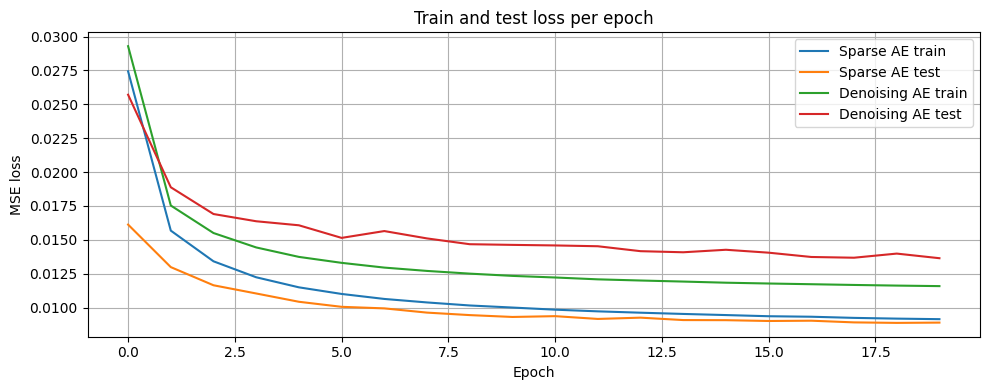

Lower test loss: Sparse AE (0.0089)


In [45]:
plt.figure(figsize=(10, 4))
epochs = range(EPOCHS)
for name, tr, te in histories_ae:
    plt.plot(epochs, tr, label=f"{name} train")
    plt.plot(epochs, te, label=f"{name} test")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Train and test loss per epoch")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
best = min(results_ae, key=lambda r: r["Test loss"])
print(f"Lower test loss: {best['Model']} ({best['Test loss']:.4f})")

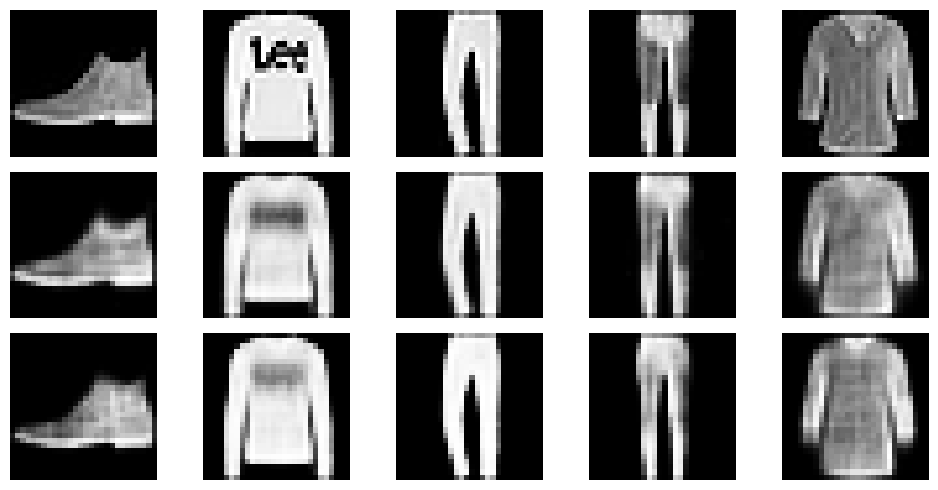

In [44]:
# Reconstructions: Original | Sparse AE | Denoising AE
sparse_model.eval()
denoise_model.eval()
images, _ = next(iter(test_loader))
x = images.view(-1, 784).to(device)
with torch.no_grad():
    recon_s, _ = sparse_model(x)
    recon_d = denoise_model(x)
x = x.cpu().view(-1, 1, 28, 28)
recon_s = recon_s.cpu().view(-1, 1, 28, 28)
recon_d = recon_d.cpu().view(-1, 1, 28, 28)
n = 5
fig, axes = plt.subplots(3, n, figsize=(2 * n, 5))
for i in range(n):
    axes[0, i].imshow(x[i, 0], cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(recon_s[i, 0], cmap="gray"); axes[1, i].axis("off")
    axes[2, i].imshow(recon_d[i, 0], cmap="gray"); axes[2, i].axis("off")
axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Sparse AE")
axes[2, 0].set_ylabel("Denoising AE")
plt.tight_layout()
plt.show()